In [5]:
import json
import os

from SIMULATION_library.fch_setup import simulation
from SIMULATION_library.cell_sims_utils import generate_bench_script

In [6]:
# Probably won't change

username                        = "crg17"
platform = "archer2"

# Particular experiment

folder_experiment_name = "HCM/2/scenarios/47"
num_beats_limit_cycle  = 500
# num_beats              = 5

# HPC
# /work/e348/e348/crg17/rodero_healthy/h11/scenarios/5/states
# states_folder = f"/rds/general/user/{username}/home/{folder_experiment_name}/states" # put here the .sv files on the hpc
states_folder = f"/work/e348/e348/{username}/{folder_experiment_name}/states" # put here the .sv files on the hpc

# Local computer
base_folder_local   = f"/media/croderog/SeagateExpansionDrive/{folder_experiment_name}"
cell_sims_basefolder = f"{base_folder_local}/cell_sims"
torord_folder       = f"{base_folder_local}/SS/param"
courtemanche_folder = f"{base_folder_local}/SS/param"
data_folder          = f"{base_folder_local}/data"
json_folder = f"{base_folder_local}/json_files"

os.makedirs(cell_sims_basefolder, exist_ok=True)


N = 800


sim_setup = simulation()
sim_setup.load(f"{json_folder}/{platform}_setup.json")

with open(f"{base_folder_local}/json_files/clinical_data.json","r") as f:
    clinical_data = json.load(f)

Loading /media/croderog/SeagateExpansionDrive/HCM/2/scenarios/47/json_files/archer2_setup.json...
Done.


# Ventricles: ToRORd_dynCl + LandHumanStress

In [17]:
generate_bench_script(N=N,								# how many simulations to run (one per param.json)
					  BCL=clinical_data["general"]["BCL"],						    	# BCL
					  NBEATS=num_beats_limit_cycle,							# NBEATS
					  basefolder=f"{base_folder_local}/SS/",				# basefolder containing the param folder
					  NPROC=23,							# number of CPUs to use for parallel runs
					  strain=0.0,								# strain
					  chamber="LV",		 						# chamber = LV, RV or atria
					  contraction_model=sim_setup.contraction_model, 		# contraction model
					  suffix="")

os.system(f"bash {base_folder_local}/SS/run_ToRORd_dynCl.sh")


mkdir: cannot create directory ‘/media/croderog/SeagateExpansionDrive/HCM/2/scenarios/47/SS/ToRORd_dynCl/’: File exists


In [20]:
generate_bench_script(N=N,								# how many simulations to run (one per param.json)
					  BCL=clinical_data["general"]["BCL"],						    	# BCL
					  NBEATS=num_beats_limit_cycle,							# NBEATS
					  basefolder=f"{base_folder_local}/SS/",				# basefolder containing the param folder
					  NPROC=23,							# number of CPUs to use for parallel runs
					  strain=0.0,								# strain
					  chamber="RV",		 						# chamber = LV, RV or atria
					  contraction_model=sim_setup.contraction_model, 		# contraction model
					  suffix="_rv")

os.system(f"bash {base_folder_local}/SS/run_ToRORd_dynCl_rv.sh")


mkdir: cannot create directory ‘/media/croderog/SeagateExpansionDrive/HCM/2/scenarios/47/SS/ToRORd_dynCl_rv/’: File exists


0

# Atria: Converted COURTEMANCHE + LandHumanStress

In [11]:
generate_bench_script(N=N,								# how many simulations to run (one per param.json)
					  BCL=clinical_data["general"]["BCL"],						    	# BCL
					  NBEATS=num_beats_limit_cycle,							# NBEATS
					  basefolder=f"{base_folder_local}/SS/",				# basefolder containing the param folder
					  NPROC=23,							# number of CPUs to use for parallel runs
					  strain=0.0,								# strain
					  chamber="atria",		 						# chamber = LV, RV or atria
					  contraction_model=sim_setup.contraction_model, 		# contraction model
					  suffix="")

os.system(f"bash {base_folder_local}/SS/run_JB_COURTEMANCHE.sh")


mkdir: cannot create directory ‘/media/croderog/SeagateExpansionDrive/HCM/2/scenarios/47/SS/JB_COURTEMANCHE/’: File exists


0

# Quality check

In [11]:
from GSA_library import ionic_output, file_utils
import matplotlib.pyplot as plt
import numpy as np
import os

In [21]:
ionic_model = "ToRORd_dynCl_rv"

ionic_output.bin_to_dat_folder(sim_foldername = f"/media/croderog/SeagateExpansionDrive/HCM/2/scenarios/47/SS/{ionic_model}/",
						  start_sample=0,
						  last_sample=799,
						  BCL=int(clinical_data["general"]["BCL"]),
						  Nbeats=int(num_beats_limit_cycle),
						  bin_files=[f"{ionic_model}.Vm.bin",f"{ionic_model}.Ca_i.bin",f"{ionic_model}.Tension.bin"],
						  output_files=[f"{ionic_model}.Vm.dat","Ca_i.dat","Tension.dat"],
						  cleanup=False)

Exception: Cannot find /media/croderog/SeagateExpansionDrive/HCM/2/scenarios/47/SS/ToRORd_dynCl_rv//0/ToRORd_dynCl_rv.Vm.bin.

In [22]:
def plot_Land_output(basefolder,
                     N,
                     figname=None,
                     isometric=False,
                     figsize=(10, 5),
                     mask=[],
                     default='',
                     color='#3489eb'):

    """
    Plot Land output calcium and tension.

    Args:
        - basefolder: containing all simulations, folder numbered from
                    0 to N-1
        - N: number of simulations to plot
        - figname: path to output figure. If None, the plot is shown
        - isometric: if True, no stretch is plotted
        - figsize: tuple, (width, height)
        - mask: boolean mask containing which simulations terminated successfully
                and which ones didn't
        - default: path to folder with Land output (Tension.dat for instance) 
                   that can be plotted against the simulations for comparison

    """

    if not isometric:
        ax = plt.figure(figsize=figsize, constrained_layout=True).subplots(1, 3)
    else:
        ax = plt.figure(figsize=figsize, constrained_layout=True).subplots(1, 2)

    plot_all = np.arange(N)
    if len(mask) > 0:
        plot_idx = plot_all[np.where(mask == 1)[0]]
    else:
        plot_idx = plot_all

    for i in plot_all:
        if not os.path.exists(basefolder+'/'+str(i)+'/Tension.dat'):
            raise Exception('Cannot find output file. The folder structure needs to be basefolder/i/Tension.dat and Ca_i.dat')

        T = file_utils.read_ionic_output(basefolder+'/'+str(i)+'/Tension.dat')
        Ca_i = file_utils.read_ionic_output(basefolder+'/'+str(i)+'/Ca_i.dat')
        t = np.arange(0, Ca_i.shape[0])

        if i in plot_idx:
            if np.max(np.abs(T)) < 500.0:
                # Plot the curve
                ax[0].plot(t, Ca_i, color=color)

                # Add a red star at the first point of the curve
                ax[0].plot(t[0], Ca_i[0], marker='*', markersize=8, color='red')

                ax[1].plot(t, T, color=color)
                ax[1].plot(t[0], T[0], marker='*', markersize=8, color='red')
        else:
            if np.max(np.abs(T)) < 500.0:
                ax[0].plot(t, Ca_i, color='black', zorder=0)
                ax[1].plot(t, T, color='black', zorder=0)

        ax[0].set_xlabel('Time [ms]')
        ax[1].set_xlabel('Time [ms]')

        ax[0].set_ylabel('Ca_i [um]')
        ax[1].set_ylabel('Tension [kPa]')

        # lambda_out = read_ionic_output(basefolder+'/'+str(i)+'/lambda.dat')
        if not isometric:
            lambda_out = file_utils.read_ionic_output(basefolder+'/'+str(i)+'/stretch.dat')
            if i in plot_idx:
                ax[2].plot(t, lambda_out, color=color)
                ax[2].plot(t[0], lambda_out[0], marker='*', markersize=8, color='red')
            else:
                ax[2].plot(t, lambda_out, color='black', zorder=0)

            ax[2].set_xlabel('Time [ms]')
            ax[2].set_ylabel('Lambda [-]')

        if default != '':
            T = file_utils.read_ionic_output(default+'/Tension.dat')
            Ca_i = file_utils.read_ionic_output(default+'/Ca_i.dat')

            ax[0].plot(t, Ca_i, '--',
                       color='black',
                       linewidth=2.0
                       )
            ax[1].plot(t, T, '--',
                       color='black',
                       linewidth=2.0
                       )

    if figname is None:
        plt.show()
    else:
        plt.savefig(figname, dpi=100)

Exception: Cannot find output file. The folder structure needs to be basefolder/i/Tension.dat and Ca_i.dat

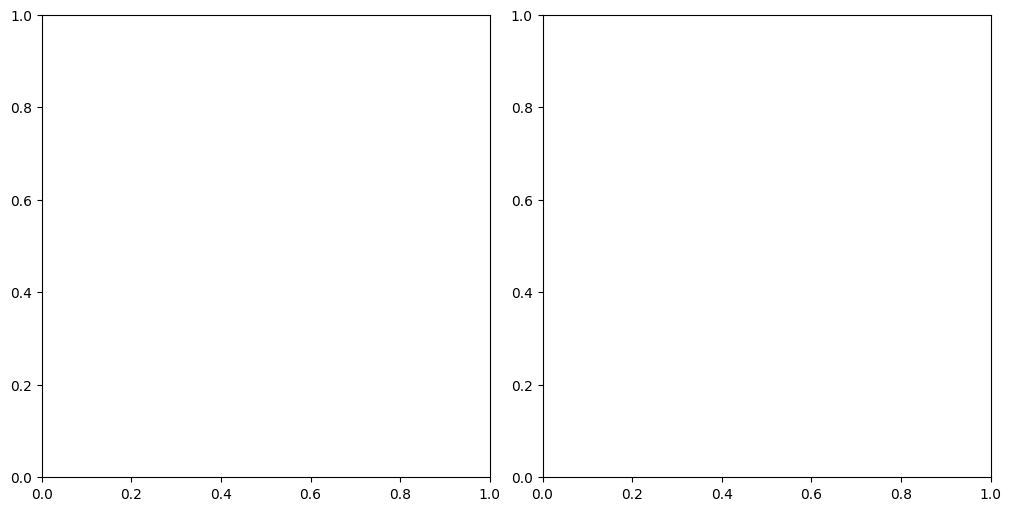

In [23]:
plot_Land_output(basefolder =  f"/media/croderog/SeagateExpansionDrive/HCM/2/scenarios/47/SS/{ionic_model}/",
                          N = 800,
                          isometric = True,
                          figname=f"/media/croderog/SeagateExpansionDrive/HCM/2/scenarios/47/SS/{ionic_model}_Land_output.png")

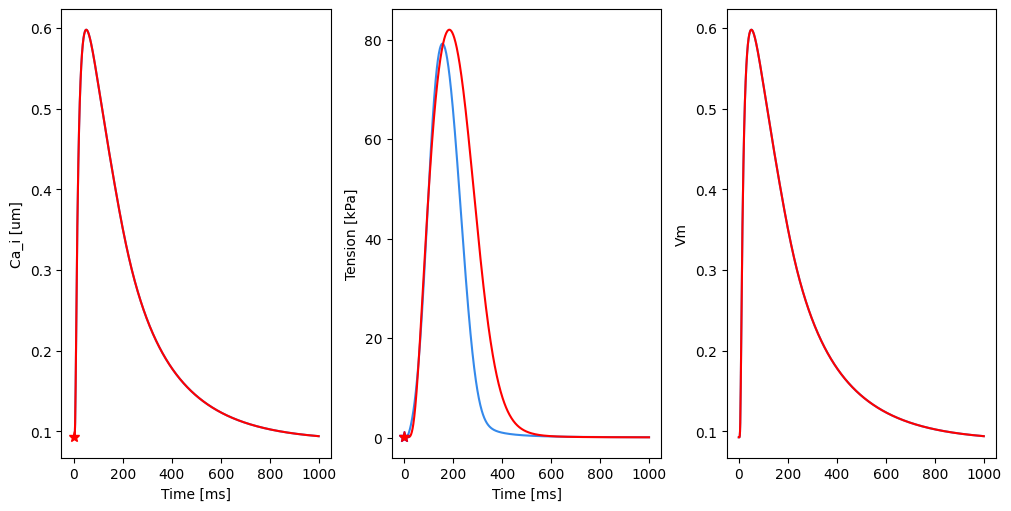

In [28]:

basefolder_1 = "/media/croderog/SeagateExpansionDrive/rodero_healthy/h11/scenarios/alex/cell_sims"
basefolder_2 = "/media/croderog/SeagateExpansionDrive/rodero_healthy/h11/scenarios/10/SS/ToRORd_dynCl/89"
BCL=1000
Nbeats = 5

bin_files = [f"ToRORd_dynCl.Vm.bin",f"ToRORd_dynCl.Ca_i.bin",f"ToRORd_dynCl.Tension.bin"]
output_files = [f"ToRORd_dynCl.Vm.dat","Land.Ca_i.dat","Land.Tension.dat"]


for j,filename in enumerate(bin_files):

    full_filename = f"{basefolder_1}/{filename}"
    ionic_output.bin_to_dat(full_filename,
                BCL,
                Nbeats,
                f"{basefolder_1}/{output_files[j]}",
                cleanup=False
                )



ax = plt.figure(figsize=(10,5), constrained_layout=True).subplots(1, 3)


T_1 = file_utils.read_ionic_output(f"{basefolder_1}/{output_files[2]}")
Ca_i_1 = file_utils.read_ionic_output(f"{basefolder_1}/{output_files[1]}")
Vm_1 = file_utils.read_ionic_output(f"{basefolder_1}/{output_files[0]}")
t_1 = np.arange(0, Ca_i_1.shape[0])

T_2 = file_utils.read_ionic_output(f"{basefolder_2}/{output_files[2]}")
Ca_i_2 = file_utils.read_ionic_output(f"{basefolder_2}/{output_files[1]}")
Vm_2 = file_utils.read_ionic_output(f"{basefolder_2}/{output_files[0]}")
t_2 = np.arange(0, Ca_i_2.shape[0])

if np.max(np.abs(T_1)) < 500.0:
        # Plot the curve
        ax[0].plot(t_1, Ca_i_1, color='#3489eb')
        ax[0].plot(t_2, Ca_i_2, color='red')

        # Add a red star at the first point of the curve
        ax[0].plot(t_1[0], Ca_i_1[0], marker='*', markersize=8, color='red')

        ax[1].plot(t_1, T_1, color='#3489eb')
        ax[1].plot(t_2, T_2, color='red')
        ax[1].plot(t_1[0], T_1[0], marker='*', markersize=8, color='blue')
        ax[1].plot(t_2[0], T_2[0], marker='*', markersize=8, color='red')


        ax[2].plot(t_1, Ca_i_1, color='#3489eb')
        ax[2].plot(t_2, Ca_i_2, color='red')
else:
    if np.max(np.abs(T_1)) < 500.0:
        ax[0].plot(t_1, Ca_i_1, color='black', zorder=0)
        ax[1].plot(t_1, T_1, color='black', zorder=0)

ax[0].set_xlabel('Time [ms]')
ax[1].set_xlabel('Time [ms]')

ax[0].set_ylabel('Ca_i [um]')
ax[1].set_ylabel('Tension [kPa]')
ax[2].set_ylabel('Vm')


plt.show()